In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# requirements for this example:
%pip install -qq docling docling-core python-dotenv langchain langchain-text-splitters langchain-huggingface chromadb langchain-community langchain-groq langchain-cohere rank_bm25 ragas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 7.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.9/282.9 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.3/223.3 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.0/319.0 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.0 MB/s eta 0:00:00
 

In [ ]:
# import libraries for docling
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import (
    PdfPipelineOptions,
    PictureDescriptionApiOptions
)
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling_core.types.doc.document import ImageRefMode
from pathlib import Path

# import libraries for RAG pipline
from dotenv import load_dotenv
from typing import Iterator
from operator import itemgetter
from typing import List
import re
from PIL import Image
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os

from langchain_core.document_loaders import BaseLoader
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_cohere import CohereRerank
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_text_splitters.markdown import MarkdownHeaderTextSplitter
from langchain_core.runnables import RunnablePassthrough
from langchain_community.document_loaders import TextLoader
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser

In [ ]:
EMBEDDINGMODEL = "all-MiniLM-L6-v2"
LLMMODEL = "llama-3.3-70b-versatile"
LLMVISIONMODEL = "meta-llama/llama-4-scout-17b-16e-instruct"

In [ ]:
pipeline_options = PdfPipelineOptions()
pipeline_options.do_formula_enrichment = True
pipeline_options.generate_picture_images=True
pipeline_options.images_scale=3

converter = DocumentConverter(format_options={
    InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
})

In [ ]:
def export_function_md_with_image_ref(conv_res, output_path:str, replace_blank:str="_"):

    output_dir = Path(output_path)
    output_dir.mkdir(parents=True, exist_ok=True)
    doc_filename = conv_res.input.file.stem.replace(" ", replace_blank)

    # Save markdown with externally referenced pictures
    md_filename = output_dir / f"{doc_filename}-with-image-refs.md"
    conv_res.document.save_as_markdown(md_filename, image_mode=ImageRefMode.REFERENCED, include_annotations=True)

In [ ]:
load_dotenv("/content/API.env")

True

In [ ]:
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
HUGGING_FACE_TOKEN = os.getenv("HUGGING_FACE_TOKEN")
COHERE_API_KEY = os.getenv("COHERE_API_KEY")

In [ ]:
files_list = ['/content/IPI_Aug_2025_EN-with-image-refs.md','/content/LMS_Q2_2025_EN-with-image-refs.md','/content/financial_statements.md']

In [ ]:
all_docs = []
for file in files_list:
  loader = TextLoader(file, encoding="utf-8")
  docs = loader.load()
  all_docs.extend(docs)

In [ ]:
all_docs

[Document(metadata={'source': '/content/IPI_Aug_2025_EN-with-image-refs.md'}, page_content='## IPI increases by 7.1% in August 2025\n\nPreliminary results indicate a 7.1% increase in the Industrial Production Index (IPI) in August 2025 compared to the same month of the previous year (August 2024), supported by the rise in mining and quarrying activity, manufacturing activity, electricity, gas, steam, and air conditioning supply activity and water supply, sewerage and waste management and remediation activities. On a monthly basis, the index increased by 1.4%.\n\n## Sub-index of mining and quarrying activity\n\nIn August 2025, the sub-index of mining and quarrying activity increased by 8.1% compared to the same month of the previous year. Saudi Arabia increased its oil production to 9.72 million barrels per day in August 2025 compared to 8.99 million barrels per day in August 2024.On a monthly basis, the sub-index of mining and quarrying activity increased by 2.1%.\n\n## Sub-index of ma

In [ ]:
class OneImagePerChunkSplitter:
    """
    Splits markdown so each image and its PRECEDING description is one chunk.
    Pattern: Description text → Figure caption → ![Image](...) = ONE CHUNK
    """

    def __init__(self, headers_to_split_on: List[tuple] = None, strip_headers: bool = False):
        self.headers_to_split_on = headers_to_split_on or [("##", "Header 2")]
        self.strip_headers = strip_headers
        self.base_splitter = MarkdownHeaderTextSplitter(
            headers_to_split_on=self.headers_to_split_on,
            strip_headers=strip_headers
        )

    def _split_by_image_blocks(self, text: str, metadata: dict) -> List[Document]:
        """
        Split text into chunks where each chunk contains:
        - Description/content before the image
        - Figure caption (e.g., "Figure1. General index...")
        - The image itself (![Image](...))
        """
        chunks = []

        # Find all images in the text
        image_pattern = r'!\[Image\]\(([^)]+)\)'
        images = list(re.finditer(image_pattern, text))

        if not images:
            # No images, return text as single chunk
            return [Document(
                page_content=text.strip(),
                metadata={**metadata, 'chunk_type': 'text_only', 'has_image': False}
            )]

        # Process text between images
        last_pos = 0

        for idx, image_match in enumerate(images):
            image_start = image_match.start()
            image_end = image_match.end()

            # Get text from last position to this image
            text_before_image = text[last_pos:image_start].strip()

            # Get the image tag
            image_tag = image_match.group(0)
            image_path = image_match.group(1)

            # Look backward to find the Figure caption (e.g., "Figure1. General index...")
            # The caption is typically on the line just before the image
            lines_before = text_before_image.split('\n')

            figure_caption = ""
            description_text = text_before_image

            # Check if last line is a Figure caption
            if lines_before and lines_before[-1].strip().startswith('Figure'):
                figure_caption = lines_before[-1].strip()
                description_text = '\n'.join(lines_before[:-1]).strip()

            # Combine: description + figure caption + image
            chunk_content = ""
            if description_text:
                chunk_content = description_text + "\n\n"
            if figure_caption:
                chunk_content += figure_caption + "\n\n"
            chunk_content += image_tag

            # Create chunk
            chunks.append(Document(
                page_content=chunk_content.strip(),
                metadata={
                    **metadata,
                    'chunk_type': 'image_with_description',
                    'has_image': True,
                    'image_index': idx + 1,
                    'figure_caption': figure_caption,
                    'image_path': image_path
                }
            ))

            last_pos = image_end

        # Add remaining text after last image (if any)
        remaining_text = text[last_pos:].strip()
        if remaining_text:
            chunks.append(Document(
                page_content=remaining_text,
                metadata={
                    **metadata,
                    'chunk_type': 'text_after_images',
                    'has_image': False
                }
            ))

        return chunks

    def _extract_header_text(self, text: str) -> tuple:
        """
        Extract header and content text separately.
        Returns (header, content)
        """
        lines = text.split('\n', 1)
        if lines[0].startswith('##'):
            header = lines[0].strip()
            content = lines[1].strip() if len(lines) > 1 else ""
            return header, content
        return "", text

    def split_text(self, text: str) -> List[Document]:
        """
        Split text by headers first, then split each section by images.
        Each image gets its own chunk with its preceding description.
        """
        # First split by headers
        header_chunks = self.base_splitter.split_text(text)

        final_chunks = []

        for chunk in header_chunks:
            section_text = chunk.page_content
            section_metadata = chunk.metadata

            # Check if this section has images
            if '![Image]' in section_text:
                # Extract header from content
                header, content = self._extract_header_text(section_text)

                # Split by images
                image_chunks = self._split_by_image_blocks(content, section_metadata)

                # Add header to first chunk if exists
                if header and image_chunks:
                    first_chunk_content = header + "\n\n" + image_chunks[0].page_content
                    image_chunks[0] = Document(
                        page_content=first_chunk_content,
                        metadata=image_chunks[0].metadata
                    )

                final_chunks.extend(image_chunks)
            else:
                # No images, keep as is
                final_chunks.append(Document(
                    page_content=section_text,
                    metadata={**section_metadata, 'chunk_type': 'text_only', 'has_image': False}
                ))

        return final_chunks

In [ ]:
headers_to_split_on = [
        ("##", "Header 2"),
    ]

splitter = OneImagePerChunkSplitter(
        headers_to_split_on=headers_to_split_on,
        strip_headers=False
    )

# Your actual example
all_chunks = []

for doc in all_docs:
  chunks = splitter.split_text(doc.page_content)
  all_chunks.extend(chunks)

print(f"✓ Total chunks created: {len(all_chunks)}\n")

for i, chunk in enumerate(all_chunks, 1):
  print(f"{'='*70}")
  print(f"CHUNK {i}")
  print(f"{'='*70}")
  print(f"Type: {chunk.metadata.get('chunk_type')}")
  print(f"Has Image: {chunk.metadata.get('has_image')}")
  print(f"Figure Caption: {chunk.metadata.get('figure_caption', 'N/A')}")
  print(f"Image Path: {chunk.metadata.get('image_path', 'N/A')}")
  print(f"Length: {len(chunk.page_content)} chars")
  print(f"\n📄 FULL CONTENT:")
  print("-" * 70)
  print(chunk.page_content)
  print("-" * 70)
  print()

✓ Total chunks created: 44

CHUNK 1
Type: text_only
Has Image: False
Figure Caption: N/A
Image Path: N/A
Length: 472 chars

📄 FULL CONTENT:
----------------------------------------------------------------------
## IPI increases by 7.1% in August 2025  
Preliminary results indicate a 7.1% increase in the Industrial Production Index (IPI) in August 2025 compared to the same month of the previous year (August 2024), supported by the rise in mining and quarrying activity, manufacturing activity, electricity, gas, steam, and air conditioning supply activity and water supply, sewerage and waste management and remediation activities. On a monthly basis, the index increased by 1.4%.
----------------------------------------------------------------------

CHUNK 2
Type: text_only
Has Image: False
Figure Caption: N/A
Image Path: N/A
Length: 408 chars

📄 FULL CONTENT:
----------------------------------------------------------------------
## Sub-index of mining and quarrying activity  
In August 202

In [ ]:
embedding_model = HuggingFaceEmbeddings(model_name=EMBEDDINGMODEL)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
persist_directory = '/content/chroma_db/'
langchain_chroma = Chroma.from_documents(documents=all_chunks,embedding=embedding_model,persist_directory=persist_directory,
                                         collection_name='MultimodelRAG')
print("Collection Created")

Collection Created


In [ ]:
llm = ChatGroq(
    groq_api_key=GROQ_API_KEY,
    model=LLMMODEL,
    temperature=0.0
)

In [ ]:
bm25_retriever = BM25Retriever.from_documents(all_chunks)
bm25_retriever.k = 4  # Return top 3 results

In [ ]:
retriever = langchain_chroma.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 4
                   }
)


In [ ]:
ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, retriever], weights=[0.5, 0.5]
)

In [ ]:
# query = "What was the index value for electricity, gas, steam and air conditioning supply in July 2025?"
# query = "What was the total revenue in 2002?"
# results = ensemble_retriever.invoke(query)

In [ ]:
# len(results)

In [ ]:
compressor = CohereRerank(model="rerank-english-v3.0",cohere_api_key=COHERE_API_KEY)
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=ensemble_retriever
)

In [ ]:
# query = "What was the labour force participation rate for Saudi males aged 55 and over in Q2 2025?"
query = "What is the monthly growth rate of manufacturing in August 2025?"
results = compression_retriever.invoke(query)

In [ ]:
def retrieve_documents(query):
    results = compression_retriever.invoke(query)
    return [result.page_content for result in results]

In [ ]:
results

[Document(metadata={'Header 2': 'IPI by main economic activities', 'chunk_type': 'image_with_description', 'has_image': True, 'image_index': 3, 'figure_caption': '', 'image_path': '/content/drive/MyDrive/RAG Techinques/output/financial_images/image_000003_4ca8909f724155c268e8f86365d906eebd318818474c4e067bca8e1d8c61b104.png', 'relevance_score': 0.9974191}, page_content='Figure3. Monthly growth rate of sub-indices according to ISIC4- August 2025  \nThe image presents a bar chart illustrating the distribution of various industries, with each industry represented by a distinct green bar and accompanied by a corresponding percentage value.  \n*   **Water supply; sewerage, waste management and remediation activities**\n*   The bar for this industry is positioned at the top of the chart.\n*   It has a value of 0.5%.\n*   **Electricity, gas, steam and air conditioning supply**\n*   This industry is represented by the second bar from the top.\n*   Its value is 3.3%.\n*   **Manufacturing**\n*   

In [ ]:
def format_docs_n(docs, n=3):
    docs = docs[:n]
    formatted = []
    for i, d in enumerate(docs, 1):
        formatted.append(
            f"[{i}]\n{d.page_content}"
        )
    return "\n\n".join(formatted)

In [ ]:
template = """
You are an expert financial analyst specializing in industrial production, manufacturing indices, and economic statistics.

Use ONLY the information from the context below (which may include text, tables, or figure descriptions) to answer the question.

⚠️ Do NOT start your answer with phrases like:
- "According to the context"
- "Based on the provided information"
- "From the document"

Just provide the answer in a clear, natural, and professional financial tone.

Strict rules:
- Use only the data provided in the context.
- Do NOT use external knowledge or assumptions.
- If the answer is not explicitly present or cannot be calculated directly from the context, say:
  "The information is not available in the provided context."
- When tables are relevant:
  - Carefully identify the correct row and column.
  - Extract values exactly as shown.
  - Preserve units, percentages, and signs (+ / -).
- If a calculation is required:
  - Show the calculation steps clearly using plain text.
  - Use only values taken from the context.
- Do NOT mention the words "context", "document", or "source" in your answer.

Context:
{context}

Question:
{question}

Answer:
"""
prompt = ChatPromptTemplate.from_template(template)


In [ ]:
chain_with_source = (
    RunnablePassthrough.assign(
        docs=itemgetter("question") | compression_retriever
    )
    | RunnablePassthrough.assign(
        context=itemgetter("docs") | RunnableLambda(format_docs_n)
    )
    | RunnablePassthrough.assign(
        answer=lambda x: (prompt | llm | StrOutputParser()).invoke({
            "context": x["context"],
            "question": x["question"]
        })
    )
)

In [ ]:
response = chain_with_source.invoke({"question": query})

In [ ]:
print(response['answer'])

The monthly growth rate of manufacturing in August 2025 is 0.3%.


In [ ]:
print(response['context'])

[1]
Figure3. Monthly growth rate of sub-indices according to ISIC4- August 2025  
The image presents a bar chart illustrating the distribution of various industries, with each industry represented by a distinct green bar and accompanied by a corresponding percentage value.  
*   **Water supply; sewerage, waste management and remediation activities**
*   The bar for this industry is positioned at the top of the chart.
*   It has a value of 0.5%.
*   **Electricity, gas, steam and air conditioning supply**
*   This industry is represented by the second bar from the top.
*   Its value is 3.3%.
*   **Manufacturing**
*   The third bar from the top corresponds to the manufacturing industry.
*   It has a value of 0.3%.
*   **Mining and quarrying**
*   The fourth bar from the top represents the mining and quarrying industry.
*   Its value is 2.1%.  
In summary, the chart effectively visualizes the relative proportions of different industries, with electricity, gas, steam, and air conditioning s

In [ ]:
def retrieve_image_paths(response):
  image_path = []
  for res in response['docs']:
    if res.metadata.get('has_image'):
      image_path.append(res.metadata.get('image_path'))

  return image_path

def display_images(image_paths):
  for path in image_paths:
    img = Image.open(path).convert("RGB")
    plt.figure()
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [ ]:
questions = [
    "What is the IPI value for mining and quarrying in June 2025?",
    "What was the unemployment rate for Saudi male youth (15–24) in Q2 2025?",
    "What was the labour force participation rate for Saudi males aged 55 and over in Q2 2025?",
    "What was the employment-to-population ratio for Saudi female individuals aged 25–54 in Q2 2025?",
    "What was the opening inventory in 2002?",
    "What were the total assets in 2002?",
    "What was the revenue in 2002?",
]


Question 1: What is the IPI value for mining and quarrying in June 2025?
Answer: The IPI value for mining and quarrying in June 2025 is 106.6.
Context: [1]
The image presents a bar chart illustrating the changes in various industries from June 2025 to August 2025. The chart is divided into four sections, each representing a different industry.  
*   **Water supply; sewerage, waste management and remediation activities**
*   June 2025: 131.6
*   July 2025: 130.9
*   August 2025: 129.9
*   **Electricity, gas, steam and air conditioning supply**
*   June 2025: 151.1
*   July 2025: 146.2
*   August 2025: 140.1
*   **Manufacturing**
*   June 2025: 124.0
*   July 2025: 123.6
*   August 2025: 119.8
*   **Mining and quarrying**
*   June 2025: 106.6
*   July 2025: 104.5
*   August 2025: 102.7  
The chart provides a clear visual representation of the fluctuations in these industries over the three-month period, allowing for easy comparison and analysis of the data.

Figure 2. IPI according to IS

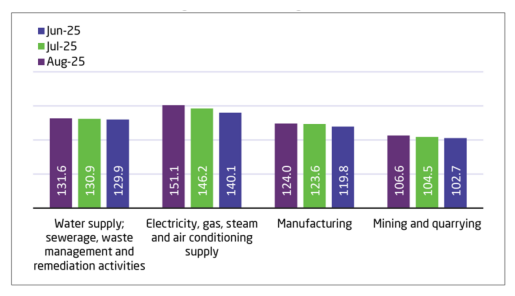

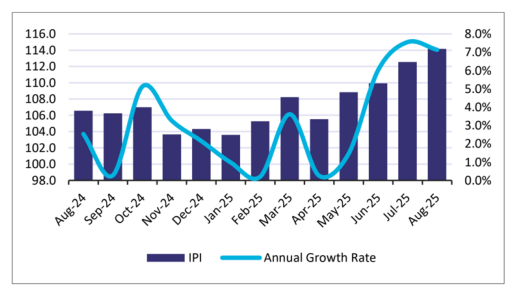



Question 2: What was the unemployment rate for Saudi male youth (15–24) in Q2 2025?
Answer: The unemployment rate for Saudi male youth (15–24) in Q2 2025 was 11.5%.
Context: [1]
## Decrease of unemployment rate for Saudi youth  
In Q2 of 2025, Saudi female youth aged 15-24 experienced a 0.8 percentage points decrease in the employment to population ratio, reaching 13.8%. Additionally, there was a  1.0  percentage  points  decrease  in  the  participation  rate,  reaching  17.4%. However,  the  unemployment  rate  decreased  by  0.1  percentage  points  reaching 20.6% compared to the previous quarter of 2025.  
On the other hand, the employment to population ratio for Saudi male youth showed a 1.2 percentage points decrease, reaching 28.0%, and recorded a 1.4 percentage points decrease  in the labor force participation  rate,  reaching  31.6%.  The unemployment rate decreased by 0.1 percentage points reaching 11.5% compared to the previous quarter of 2025.  
The results concerning lab

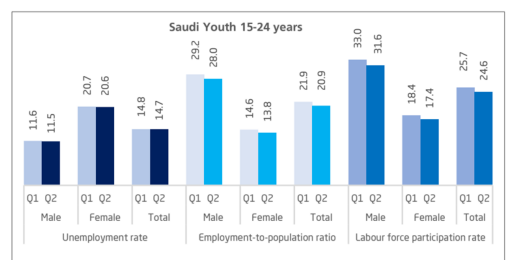



Question 3: What was the labour force participation rate for Saudi males aged 55 and over in Q2 2025?
Answer: The labour force participation rate for Saudi males aged 55 and over in Q2 2025 was 35.6%.
Context: [1]
## Decrease of unemployment rate for Saudi youth  
In Q2 of 2025, Saudi female youth aged 15-24 experienced a 0.8 percentage points decrease in the employment to population ratio, reaching 13.8%. Additionally, there was a  1.0  percentage  points  decrease  in  the  participation  rate,  reaching  17.4%. However,  the  unemployment  rate  decreased  by  0.1  percentage  points  reaching 20.6% compared to the previous quarter of 2025.  
On the other hand, the employment to population ratio for Saudi male youth showed a 1.2 percentage points decrease, reaching 28.0%, and recorded a 1.4 percentage points decrease  in the labor force participation  rate,  reaching  31.6%.  The unemployment rate decreased by 0.1 percentage points reaching 11.5% compared to the previous quarter o

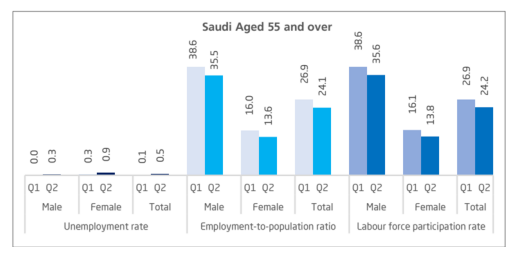



Question 4: What was the employment-to-population ratio for Saudi female individuals aged 25–54 in Q2 2025?
Answer: The information is not available in the provided context.
Context: [1]
## Decrease of unemployment rate for Saudi youth  
In Q2 of 2025, Saudi female youth aged 15-24 experienced a 0.8 percentage points decrease in the employment to population ratio, reaching 13.8%. Additionally, there was a  1.0  percentage  points  decrease  in  the  participation  rate,  reaching  17.4%. However,  the  unemployment  rate  decreased  by  0.1  percentage  points  reaching 20.6% compared to the previous quarter of 2025.  
On the other hand, the employment to population ratio for Saudi male youth showed a 1.2 percentage points decrease, reaching 28.0%, and recorded a 1.4 percentage points decrease  in the labor force participation  rate,  reaching  31.6%.  The unemployment rate decreased by 0.1 percentage points reaching 11.5% compared to the previous quarter of 2025.  
The results conce

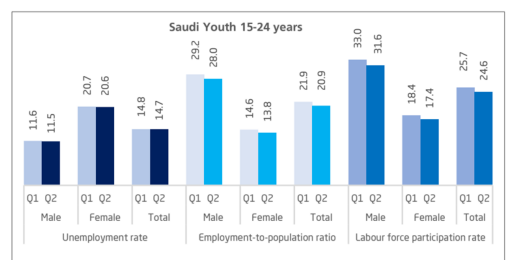



Question 5: What was the opening inventory in 2002?
Answer: The opening inventory in 2002 was $156,657.
Context: [1]
## XYZ COMPANY LIMITED STATEMENT OF INCOME AND RETAINED EARNINGS  
FOR THE YEAR ENDED JUNE 30, 2002  
UNAUDITED - See "Notice to Reader"  
This table shows the company’s income statement for 2002 and 2001, including revenue, cost of sales, gross profit, operating expenses, income from operations, other income and expenses, net income, and changes in retained earnings for each year.  
|                                                   | 2002        | 2001        |
|---------------------------------------------------|-------------|-------------|
| REVENUE                                           | $ 1,104,786 | $ 1,133,736 |
| COST OF SALES                                     |             |             |
| Opening inventory                                 | 156,657     | 146,278     |
| Delivery                                          | 1,607       | 1,249       |
| 

In [ ]:
for i, question in enumerate(questions, 1):

  response = chain_with_source.invoke({"question": question})

  print(f"Question {i}: {question}")
  print(f"Answer: {response['answer']}")
  print(f"Context: {response['context']}")
  image_path = retrieve_image_paths(response)
  if image_path:
    print("Images:")
    display_images(image_path)
  else:
    print("No images found in the context.")
  print("\n" + "=" * 50 + "\n")